# Логистическая регрессия: классификация, регуляризация, кросс-валидация

Датасет: **Breast Cancer Wisconsin** (`load_breast_cancer` из sklearn) — бинарная классификация (malignant/benign), 569 записей, 30 признаков.

**Задачи:**
1. Предобработка и EDA
2. Обучение логистической регрессии + кросс-валидация
3. Оценка модели: confusion matrix, classification report, AUC-ROC
4. Определение оптимального порога
5. Precision vs Recall — что важнее
6. Регуляризация (L1, L2, ElasticNet)
7. **Бонус:** мультиклассовая классификация (Wine dataset)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer, load_wine
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_curve, auc,
    precision_score, recall_score, f1_score, accuracy_score,
    ConfusionMatrixDisplay, RocCurveDisplay
)

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 100

## 1. Загрузка и обзор данных

In [2]:
cancer = load_breast_cancer()
df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
df['target'] = cancer.target  # 0 = malignant, 1 = benign

print(f'Классы: {dict(enumerate(cancer.target_names))}')
print(f'Размер: {df.shape}')
df.head()

Классы: {0: np.str_('malignant'), 1: np.str_('benign')}
Размер: (569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

In [4]:
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


## 2. EDA (разведочный анализ)

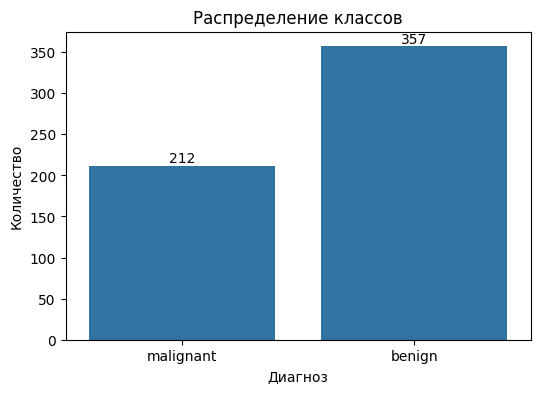

Malignant (0): 212 (37.3%)
Benign (1):    357 (62.7%)


In [5]:
# Распределение классов
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='target', data=df)
ax.set_xticklabels(cancer.target_names)
plt.title('Распределение классов')
plt.xlabel('Диагноз')
plt.ylabel('Количество')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
               ha='center', va='bottom')
plt.show()

print(f'Malignant (0): {(df["target"] == 0).sum()} ({(df["target"] == 0).mean():.1%})')
print(f'Benign (1):    {(df["target"] == 1).sum()} ({(df["target"] == 1).mean():.1%})')

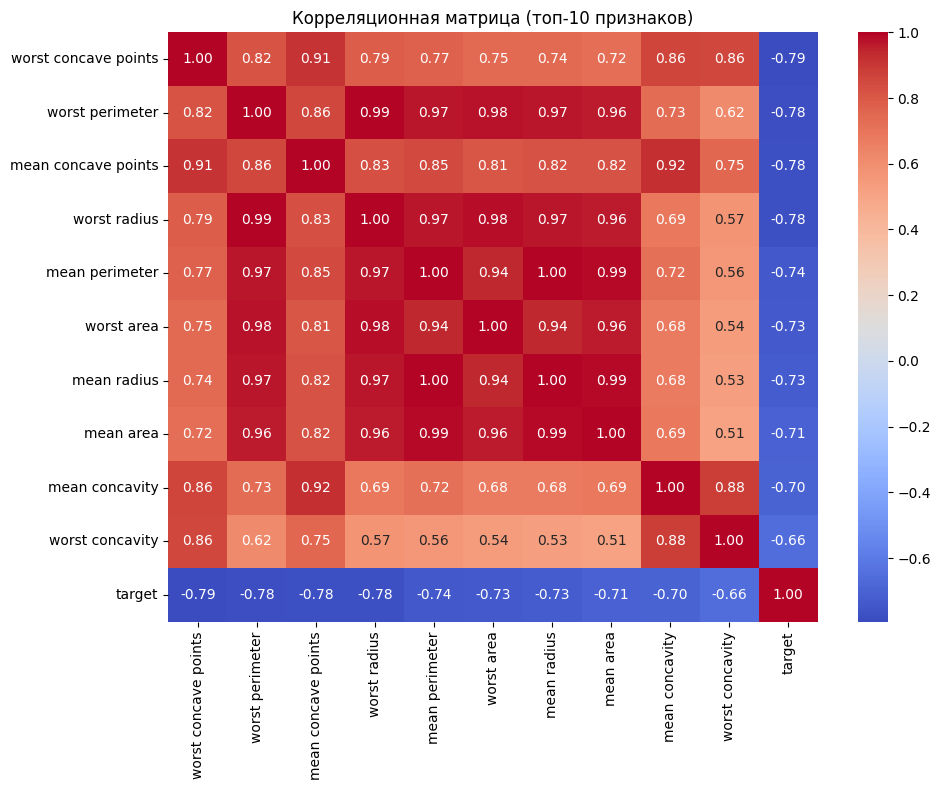

In [6]:
# Корреляционная матрица (топ-10 признаков по корреляции с target)
corr_with_target = df.corr()['target'].drop('target').abs().sort_values(ascending=False)
top_features = corr_with_target.head(10).index.tolist()

plt.figure(figsize=(10, 8))
sns.heatmap(df[top_features + ['target']].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Корреляционная матрица (топ-10 признаков)')
plt.tight_layout()
plt.show()

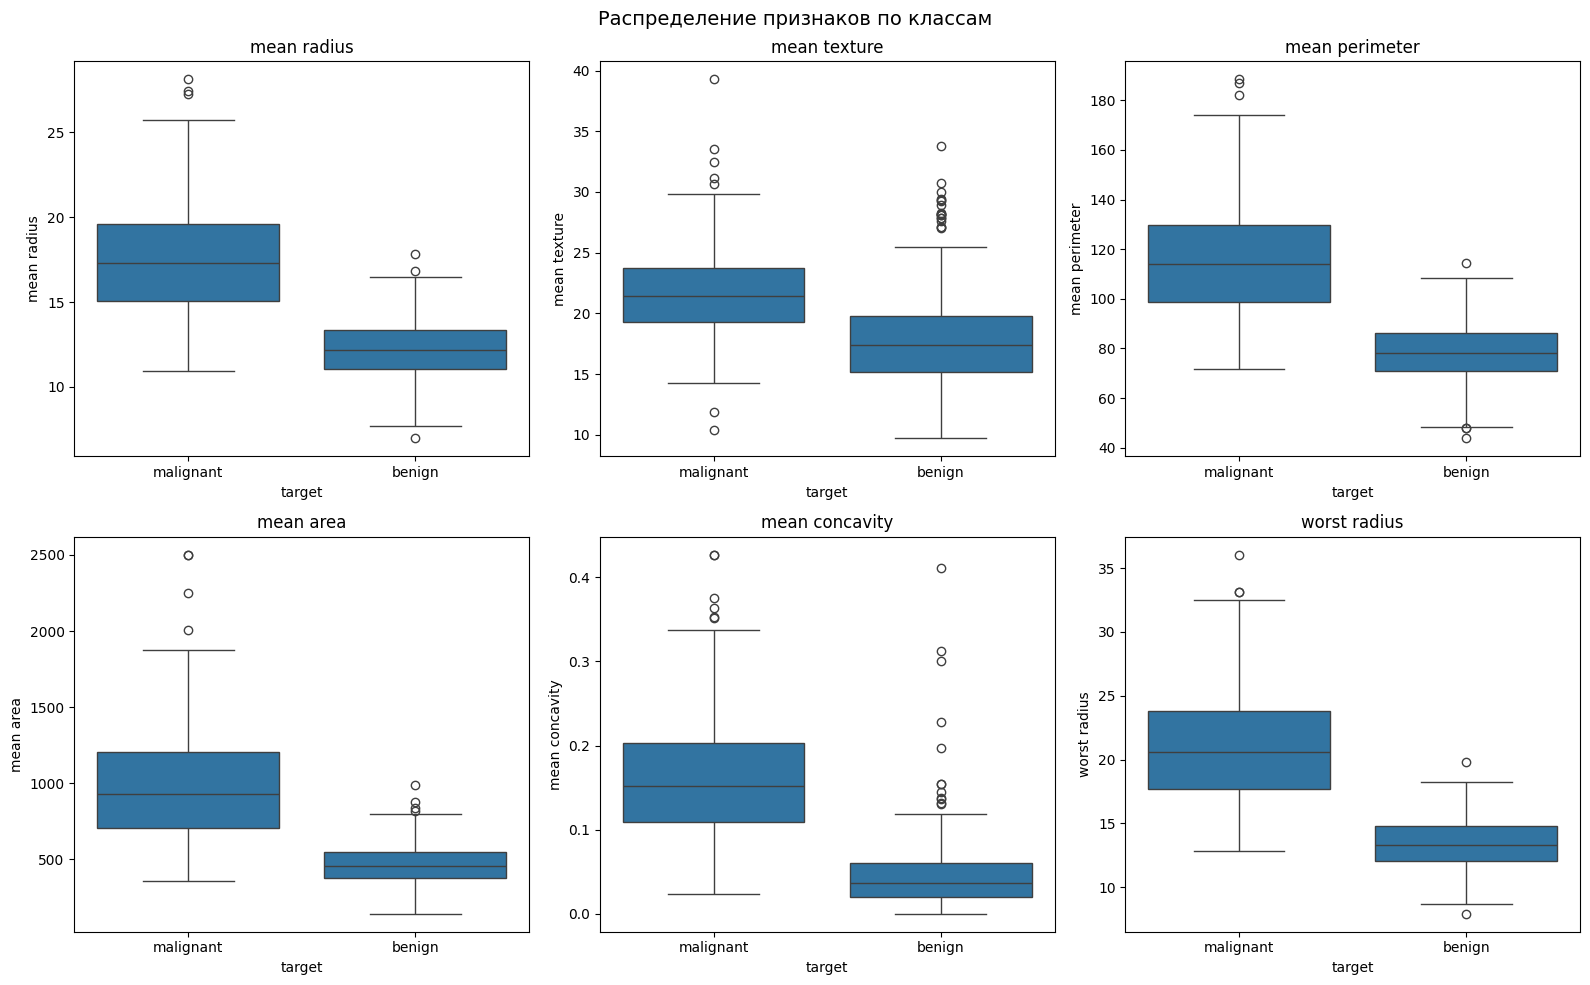

In [7]:
# Boxplots ключевых признаков по классам
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
key_features = ['mean radius', 'mean texture', 'mean perimeter',
                'mean area', 'mean concavity', 'worst radius']

for ax, feat in zip(axes.flat, key_features):
    sns.boxplot(x='target', y=feat, data=df, ax=ax)
    ax.set_xticklabels(cancer.target_names)
    ax.set_title(feat)

plt.suptitle('Распределение признаков по классам', fontsize=14)
plt.tight_layout()
plt.show()

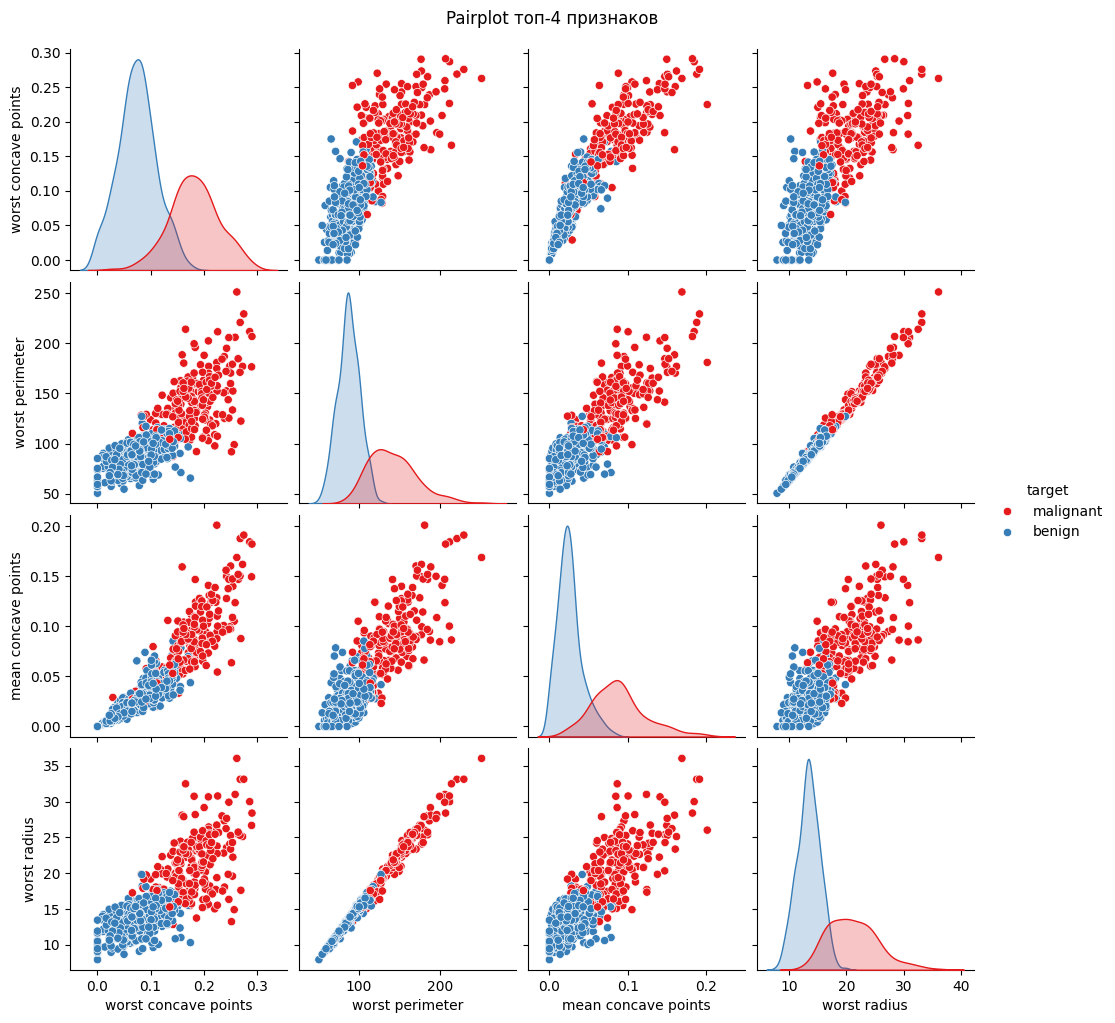

In [8]:
# Pairplot топ-4 признаков
top4 = corr_with_target.head(4).index.tolist()
plot_df = df[top4 + ['target']].copy()
plot_df['target'] = plot_df['target'].map({0: 'malignant', 1: 'benign'})

sns.pairplot(plot_df, hue='target', diag_kind='kde', palette='Set1')
plt.suptitle('Pairplot топ-4 признаков', y=1.02)
plt.show()

## 3. Предобработка

In [9]:
# Проверка пропусков
print('Пропуски по столбцам:')
print(df.isnull().sum().sum())
print('Пропусков нет — данные чистые.')

Пропуски по столбцам:
0
Пропусков нет — данные чистые.


In [10]:
# Train/test split
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_train.shape[0]} samples')
print(f'Test:  {X_test.shape[0]} samples')
print(f'\nРаспределение классов в train: {y_train.value_counts().to_dict()}')
print(f'Распределение классов в test:  {y_test.value_counts().to_dict()}')

Train: 455 samples
Test:  114 samples

Распределение классов в train: {1: 285, 0: 170}
Распределение классов в test:  {1: 72, 0: 42}


In [11]:
# StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Стандартизация выполнена (fit на train, transform на test).')

Стандартизация выполнена (fit на train, transform на test).


## 4. Логистическая регрессия — базовая модель

In [12]:
# Обучение базовой модели
log_reg = LogisticRegression(random_state=42, max_iter=10000)
log_reg.fit(X_train_scaled, y_train)

y_pred = log_reg.predict(X_test_scaled)
y_prob = log_reg.predict_proba(X_test_scaled)[:, 1]

print(f'Accuracy на тестовой выборке: {accuracy_score(y_test, y_pred):.4f}')

Accuracy на тестовой выборке: 0.9825


In [13]:
# Кросс-валидация (5-fold)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(log_reg, X_train_scaled, y_train, cv=cv, scoring='accuracy')

print(f'Cross-validation accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})')
print(f'По фолдам: {[f"{s:.4f}" for s in cv_scores]}')

Cross-validation accuracy: 0.9780 (+/- 0.0098)
По фолдам: ['0.9670', '0.9890', '0.9780', '0.9890', '0.9670']


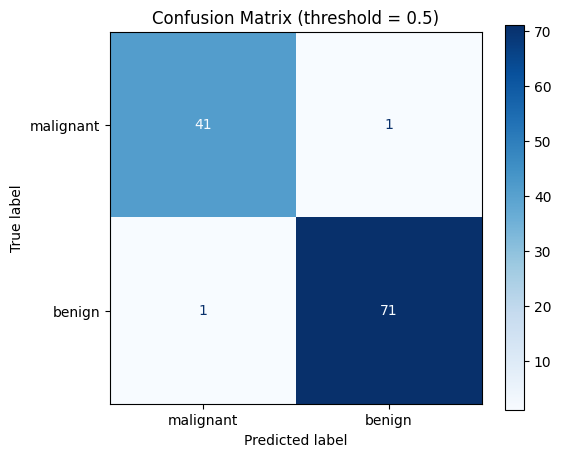


TN=41, FP=1, FN=1, TP=71


In [14]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=cancer.target_names)
disp.plot(cmap='Blues', ax=ax)
plt.title('Confusion Matrix (threshold = 0.5)')
plt.show()

print(f'\nTN={cm[0,0]}, FP={cm[0,1]}, FN={cm[1,0]}, TP={cm[1,1]}')

In [15]:
# Classification Report
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=cancer.target_names))

Classification Report:
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



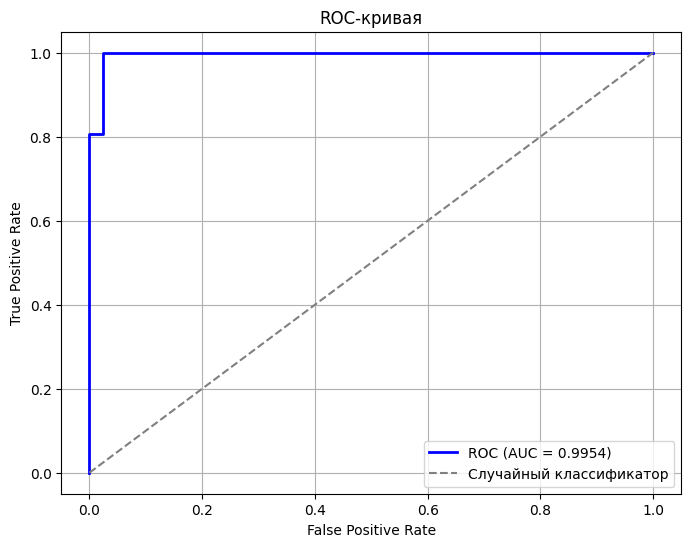

AUC-ROC: 0.9954


In [16]:
# ROC-кривая и AUC
fpr, tpr, thresholds_roc = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Случайный классификатор')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривая')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print(f'AUC-ROC: {roc_auc:.4f}')

## 5. Оптимальный порог (threshold)

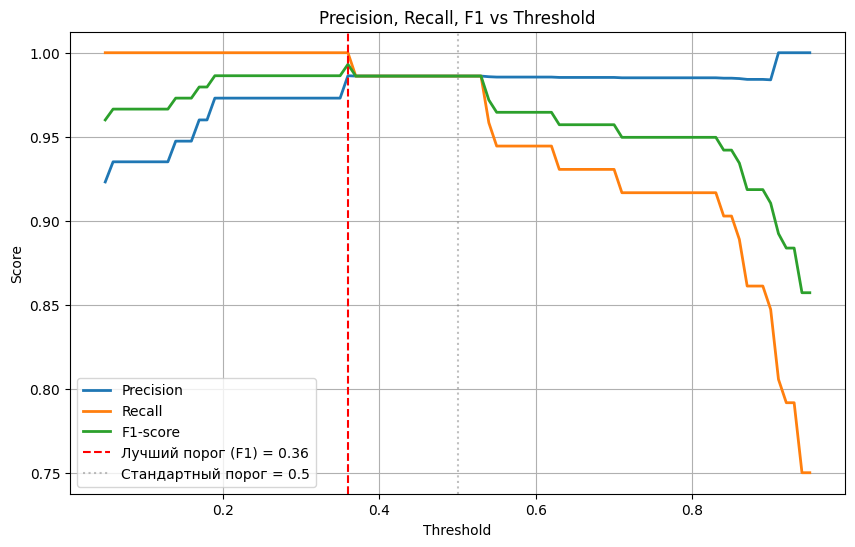

Лучший порог по F1: 0.36
F1 при этом пороге: 0.9931
Precision: 0.9863, Recall: 1.0000


In [17]:
# Перебор threshold от 0.05 до 0.95
thresholds = np.arange(0.05, 0.96, 0.01)
precisions = []
recalls = []
f1_scores = []

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    precisions.append(precision_score(y_test, y_pred_t, zero_division=0))
    recalls.append(recall_score(y_test, y_pred_t))
    f1_scores.append(f1_score(y_test, y_pred_t, zero_division=0))

# График precision/recall/f1 vs threshold
plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions, label='Precision', linewidth=2)
plt.plot(thresholds, recalls, label='Recall', linewidth=2)
plt.plot(thresholds, f1_scores, label='F1-score', linewidth=2)

best_f1_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_f1_idx]
plt.axvline(x=best_threshold, color='red', linestyle='--', label=f'Лучший порог (F1) = {best_threshold:.2f}')
plt.axvline(x=0.5, color='gray', linestyle=':', alpha=0.5, label='Стандартный порог = 0.5')

plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision, Recall, F1 vs Threshold')
plt.legend()
plt.grid(True)
plt.show()

print(f'Лучший порог по F1: {best_threshold:.2f}')
print(f'F1 при этом пороге: {f1_scores[best_f1_idx]:.4f}')
print(f'Precision: {precisions[best_f1_idx]:.4f}, Recall: {recalls[best_f1_idx]:.4f}')

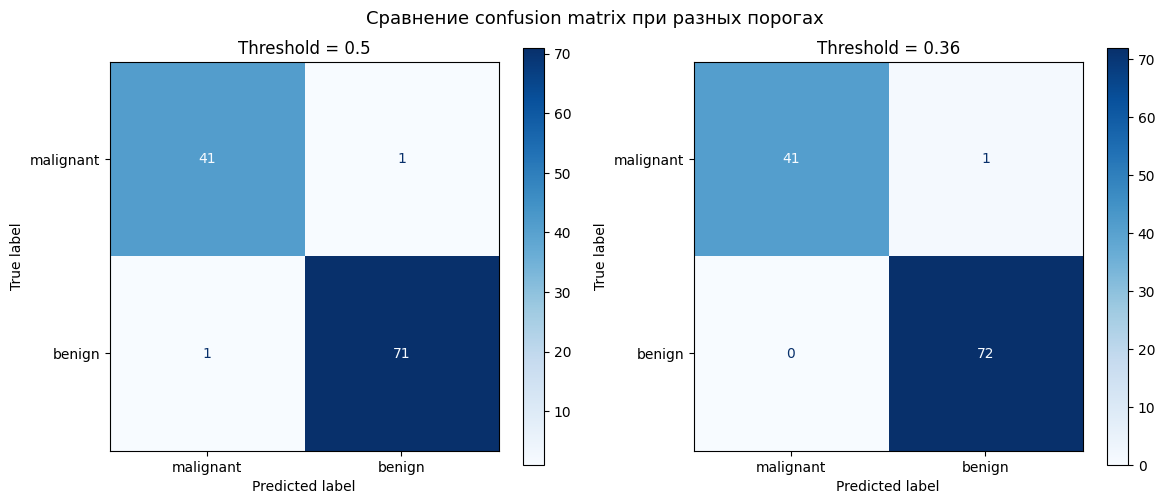

In [18]:
# Сравнение confusion matrix при стандартном и оптимальном пороге
y_pred_optimal = (y_prob >= best_threshold).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, y_pred),
    display_labels=cancer.target_names
).plot(cmap='Blues', ax=axes[0])
axes[0].set_title('Threshold = 0.5')

ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, y_pred_optimal),
    display_labels=cancer.target_names
).plot(cmap='Blues', ax=axes[1])
axes[1].set_title(f'Threshold = {best_threshold:.2f}')

plt.suptitle('Сравнение confusion matrix при разных порогах', fontsize=13)
plt.tight_layout()
plt.show()

## 6. Precision vs Recall — что важнее?

В контексте диагностики рака молочной железы:

- **False Negative (FN)** = пропустить рак → пациент не получит лечение → **опасно для жизни**
- **False Positive (FP)** = ложная тревога → дополнительные обследования → стресс, но не смертельно

Поэтому **Recall (полнота) важнее Precision** в данной задаче:

- **Recall** = TP / (TP + FN) — какую долю реально больных мы нашли
- Нам нужно минимизировать FN, даже ценой увеличения FP

Если бы мы хотели максимизировать recall, мы бы **понизили порог** (например, до 0.3), чтобы модель чаще предсказывала "benign" (1) и не пропускала случаи malignant (0).

**Примечание:** в нашем датасете target=0 это malignant, target=1 это benign. Для задачи "не пропустить рак" нужно высокий recall для класса malignant, что означает минимум FN для класса 0.

In [19]:
# Демонстрация: понижение порога для максимизации recall класса malignant
print('=== Влияние порога на recall класса malignant (0) ===\n')
for t in [0.3, 0.4, 0.5, 0.6, 0.7]:
    y_pred_t = (y_prob >= t).astype(int)
    recall_mal = recall_score(y_test, y_pred_t, pos_label=0)
    recall_ben = recall_score(y_test, y_pred_t, pos_label=1)
    acc = accuracy_score(y_test, y_pred_t)
    print(f'Threshold={t:.1f}: Recall(malignant)={recall_mal:.4f}, Recall(benign)={recall_ben:.4f}, Accuracy={acc:.4f}')

=== Влияние порога на recall класса malignant (0) ===

Threshold=0.3: Recall(malignant)=0.9524, Recall(benign)=1.0000, Accuracy=0.9825
Threshold=0.4: Recall(malignant)=0.9762, Recall(benign)=0.9861, Accuracy=0.9825
Threshold=0.5: Recall(malignant)=0.9762, Recall(benign)=0.9861, Accuracy=0.9825
Threshold=0.6: Recall(malignant)=0.9762, Recall(benign)=0.9444, Accuracy=0.9561
Threshold=0.7: Recall(malignant)=0.9762, Recall(benign)=0.9306, Accuracy=0.9474


## 7. Регуляризация — сравнение L1, L2, ElasticNet

In [20]:
# Сравнение типов регуляризации
penalties = {
    'L2 (Ridge)': {'penalty': 'l2', 'solver': 'lbfgs'},
    'L1 (Lasso)': {'penalty': 'l1', 'solver': 'saga'},
    'ElasticNet':  {'penalty': 'elasticnet', 'solver': 'saga', 'l1_ratio': 0.5},
}

C_values = np.logspace(-4, 4, 20)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results_reg = {}
for name, params in penalties.items():
    cv_means = []
    for C in C_values:
        model = LogisticRegression(C=C, random_state=42, max_iter=10000, **params)
        scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='accuracy')
        cv_means.append(scores.mean())
    results_reg[name] = cv_means
    best_idx = np.argmax(cv_means)
    print(f'{name}: лучший C={C_values[best_idx]:.4f}, accuracy={cv_means[best_idx]:.4f}')

L2 (Ridge): лучший C=0.0886, accuracy=0.9824


L1 (Lasso): лучший C=0.2336, accuracy=0.9670


ElasticNet: лучший C=0.0886, accuracy=0.9802


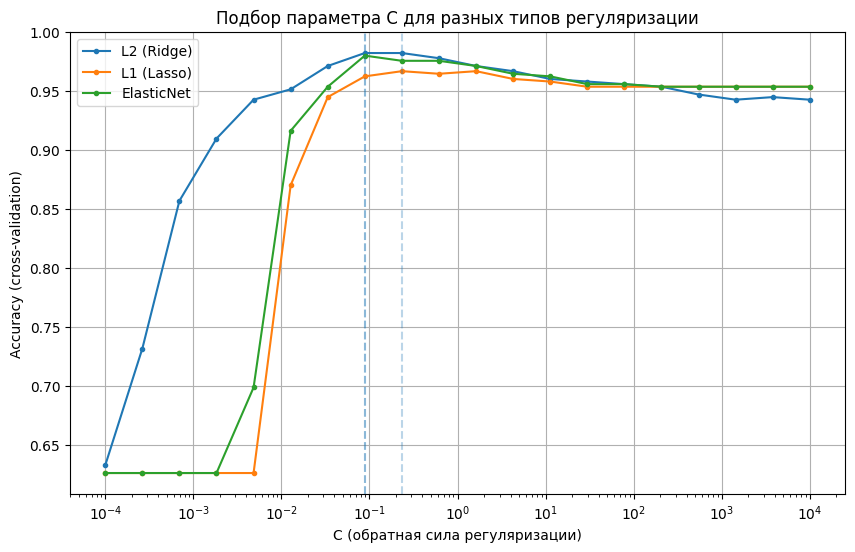

In [21]:
# График: C vs Accuracy для каждого типа регуляризации
plt.figure(figsize=(10, 6))
for name, cv_means in results_reg.items():
    best_idx = np.argmax(cv_means)
    plt.plot(C_values, cv_means, marker='.', label=name)
    plt.axvline(x=C_values[best_idx], linestyle='--', alpha=0.3)

plt.xscale('log')
plt.xlabel('C (обратная сила регуляризации)')
plt.ylabel('Accuracy (cross-validation)')
plt.title('Подбор параметра C для разных типов регуляризации')
plt.legend()
plt.grid(True)
plt.show()

In [22]:
# Таблица сравнения лучших моделей
comparison = []

for name, params in penalties.items():
    cv_means = results_reg[name]
    best_idx = np.argmax(cv_means)
    best_C = C_values[best_idx]
    
    model = LogisticRegression(C=best_C, random_state=42, max_iter=10000, **params)
    model.fit(X_train_scaled, y_train)
    y_pred_m = model.predict(X_test_scaled)
    y_prob_m = model.predict_proba(X_test_scaled)[:, 1]
    
    fpr_m, tpr_m, _ = roc_curve(y_test, y_prob_m)
    
    comparison.append({
        'Модель': name,
        'C': round(best_C, 4),
        'Accuracy': round(accuracy_score(y_test, y_pred_m), 4),
        'Precision': round(precision_score(y_test, y_pred_m), 4),
        'Recall': round(recall_score(y_test, y_pred_m), 4),
        'F1': round(f1_score(y_test, y_pred_m), 4),
        'AUC-ROC': round(auc(fpr_m, tpr_m), 4),
        'Ненулевых коэф.': int(np.sum(model.coef_[0] != 0)),
    })

comparison_df = pd.DataFrame(comparison)
comparison_df

,Модель,C,Accuracy,Precision,Recall,F1,AUC-ROC,Ненулевых коэф.
0,L2 (Ridge),0.0886,0.9737,0.9726,0.9861,0.9793,0.9957,30
1,L1 (Lasso),0.2336,0.9649,0.9595,0.9861,0.9726,0.9960,9
2,ElasticNet,0.0886,0.9649,0.9595,0.9861,0.9726,0.9957,19


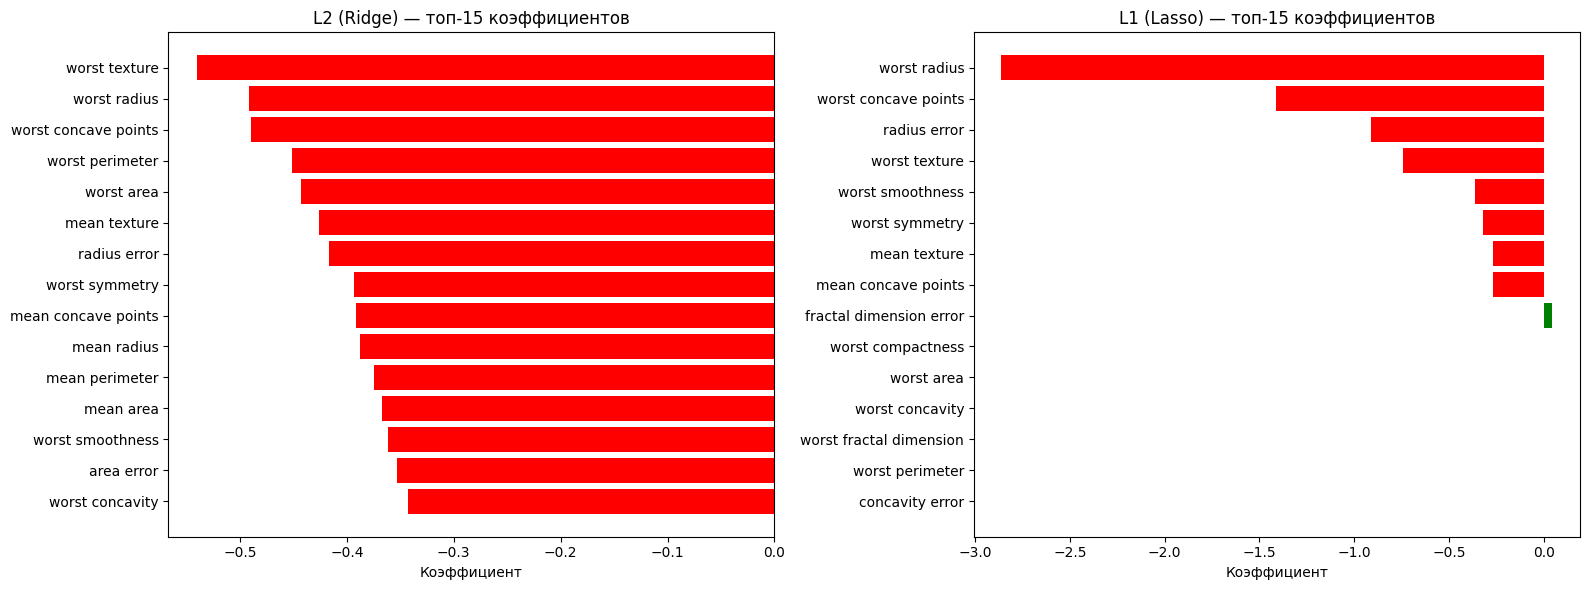

In [23]:
# Визуализация коэффициентов L1 vs L2
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (name, params) in zip(axes, [('L2 (Ridge)', penalties['L2 (Ridge)']),
                                      ('L1 (Lasso)', penalties['L1 (Lasso)'])]):
    best_idx = np.argmax(results_reg[name])
    best_C = C_values[best_idx]
    model = LogisticRegression(C=best_C, random_state=42, max_iter=10000, **params)
    model.fit(X_train_scaled, y_train)
    
    coefs = model.coef_[0]
    sorted_idx = np.argsort(np.abs(coefs))[::-1]
    top_n = 15
    
    colors = ['green' if c > 0 else 'red' for c in coefs[sorted_idx[:top_n]]]
    ax.barh(range(top_n), coefs[sorted_idx[:top_n]], color=colors)
    ax.set_yticks(range(top_n))
    ax.set_yticklabels(np.array(cancer.feature_names)[sorted_idx[:top_n]])
    ax.set_xlabel('Коэффициент')
    ax.set_title(f'{name} — топ-15 коэффициентов')
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

## 8. Бонус: мультиклассовая классификация (Wine dataset)

In [24]:
# Загрузка данных
wine = load_wine()
df_wine = pd.DataFrame(wine.data, columns=wine.feature_names)
df_wine['target'] = wine.target

print(f'Классы: {dict(enumerate(wine.target_names))}')
print(f'Размер: {df_wine.shape}')
print(f'\nРаспределение классов:\n{df_wine["target"].value_counts().sort_index()}')

Классы: {0: np.str_('class_0'), 1: np.str_('class_1'), 2: np.str_('class_2')}
Размер: (178, 14)

Распределение классов:
target
0    59
1    71
2    48
Name: count, dtype: int64


In [25]:
# Train/test split и стандартизация
X_wine = df_wine.drop('target', axis=1)
y_wine = df_wine['target']

X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(
    X_wine, y_wine, test_size=0.2, random_state=42, stratify=y_wine
)

scaler_w = StandardScaler()
X_train_w_scaled = scaler_w.fit_transform(X_train_w)
X_test_w_scaled = scaler_w.transform(X_test_w)

print(f'Train: {X_train_w_scaled.shape[0]}, Test: {X_test_w_scaled.shape[0]}')

Train: 142, Test: 36


In [26]:
# Логистическая регрессия (OvR по умолчанию для мультикласса)
log_reg_wine = LogisticRegression(
    random_state=42, max_iter=10000, C=1.0
)
log_reg_wine.fit(X_train_w_scaled, y_train_w)

y_pred_wine = log_reg_wine.predict(X_test_w_scaled)

# Кросс-валидация
cv_wine = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_wine = cross_val_score(log_reg_wine, X_train_w_scaled, y_train_w, cv=cv_wine, scoring='accuracy')
print(f'Cross-validation accuracy: {cv_scores_wine.mean():.4f} (+/- {cv_scores_wine.std():.4f})')
print(f'Test accuracy: {accuracy_score(y_test_w, y_pred_wine):.4f}')

Cross-validation accuracy: 0.9791 (+/- 0.0277)
Test accuracy: 0.9722


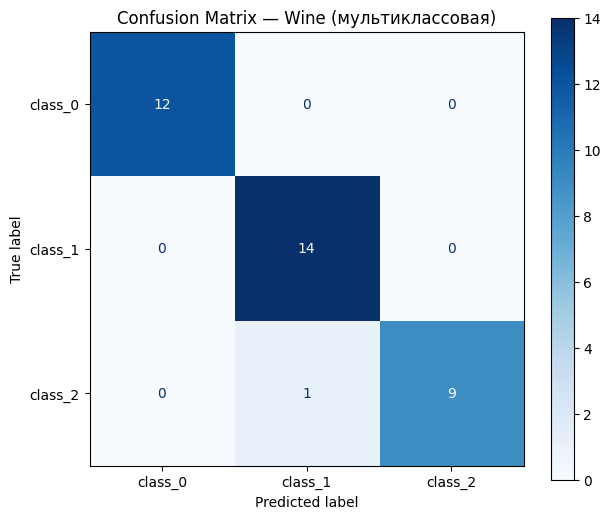


Classification Report:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       0.93      1.00      0.97        14
     class_2       1.00      0.90      0.95        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36



In [27]:
# Confusion Matrix
cm_wine = confusion_matrix(y_test_w, y_pred_wine)

fig, ax = plt.subplots(figsize=(7, 6))
disp_wine = ConfusionMatrixDisplay(confusion_matrix=cm_wine, display_labels=wine.target_names)
disp_wine.plot(cmap='Blues', ax=ax)
plt.title('Confusion Matrix — Wine (мультиклассовая)')
plt.show()

print('\nClassification Report:')
print(classification_report(y_test_w, y_pred_wine, target_names=wine.target_names))

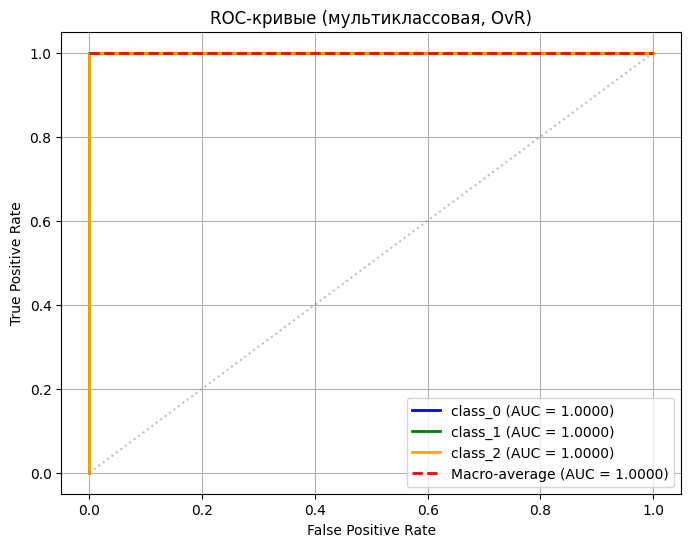

Macro-average AUC-ROC: 1.0000


In [28]:
# ROC-кривая для мультиклассовой задачи (One-vs-Rest)
y_test_w_bin = label_binarize(y_test_w, classes=[0, 1, 2])
y_prob_wine = log_reg_wine.predict_proba(X_test_w_scaled)

plt.figure(figsize=(8, 6))
colors = ['blue', 'green', 'orange']

for i, (color, name) in enumerate(zip(colors, wine.target_names)):
    fpr_i, tpr_i, _ = roc_curve(y_test_w_bin[:, i], y_prob_wine[:, i])
    auc_i = auc(fpr_i, tpr_i)
    plt.plot(fpr_i, tpr_i, color=color, lw=2, label=f'{name} (AUC = {auc_i:.4f})')

# Macro-average ROC
all_fpr = np.unique(np.concatenate([roc_curve(y_test_w_bin[:, i], y_prob_wine[:, i])[0] for i in range(3)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(3):
    fpr_i, tpr_i, _ = roc_curve(y_test_w_bin[:, i], y_prob_wine[:, i])
    mean_tpr += np.interp(all_fpr, fpr_i, tpr_i)
mean_tpr /= 3
macro_auc = auc(all_fpr, mean_tpr)
plt.plot(all_fpr, mean_tpr, color='red', lw=2, linestyle='--', label=f'Macro-average (AUC = {macro_auc:.4f})')

plt.plot([0, 1], [0, 1], color='gray', linestyle=':', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривые (мультиклассовая, OvR)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print(f'Macro-average AUC-ROC: {macro_auc:.4f}')

## Итоги

1. **Логистическая регрессия** показала высокую точность на Breast Cancer (~97% accuracy)
2. **Кросс-валидация** подтвердила устойчивость результатов
3. **AUC-ROC** близок к 1.0 — модель отлично разделяет классы
4. **Оптимальный порог** подобран через анализ precision/recall/F1 vs threshold
5. В медицинском контексте **Recall важнее Precision** — лучше ложная тревога, чем пропущенный рак
6. **L1-регуляризация** (Lasso) автоматически отбирает важные признаки, обнуляя ненужные
7. **Бонус:** мультиклассовая логистическая регрессия (OvR) на Wine dataset — macro AUC-ROC высокий